In [1]:
from xgboost import XGBClassifier
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE, ADASYN, SMOTENC
import shap


c:\Users\wenyu\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("data/train-cat-encoded.csv")
print("Training set size: ", df.shape)
y = df['Will_Buy_EV']
x = df.drop(columns=['Will_Buy_EV'])
x = x.drop(columns=['id'])
binary_features = ['Home_Charging_Possible', 'Subsidy_Available', 
                     'City_Type_Urban', 'City_Type_Suburban', 'City_Type_Rural', 
                     'Current_Car_Type_Sedan', 'Current_Car_Type_SUV', 
                     'Current_Car_Type_Hatchback', 'Current_Car_Type_Truck', 
                     'Gender_Male', 'Gender_Female', 'Gender_Other']
print(binary_features)


Training set size:  (668665, 22)
['Home_Charging_Possible', 'Subsidy_Available', 'City_Type_Urban', 'City_Type_Suburban', 'City_Type_Rural', 'Current_Car_Type_Sedan', 'Current_Car_Type_SUV', 'Current_Car_Type_Hatchback', 'Current_Car_Type_Truck', 'Gender_Male', 'Gender_Female', 'Gender_Other']


In [3]:
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
subsetNum = 100000
subset_x = x.iloc[:subsetNum]
subset_y = y.iloc[:subsetNum]
smote = SMOTENC(
    random_state=42,
    categorical_features=binary_features)
ada = ADASYN(n_neighbors=5, random_state=42)


==========XGBoost Cross Validation Training Loop==========

========== FOLD 1 ==========
Fold 1 | AUC: 0.9362
F1: 0.6995 | Recall: 0.7440 | Precision: 0.6601


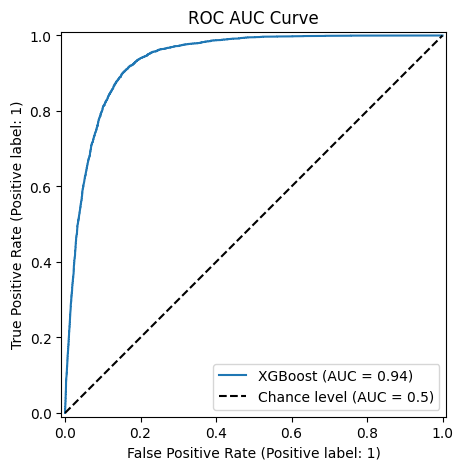

Finished Fold 1

========== FOLD 2 ==========
Fold 2 | AUC: 0.9372
F1: 0.7027 | Recall: 0.7399 | Precision: 0.6690


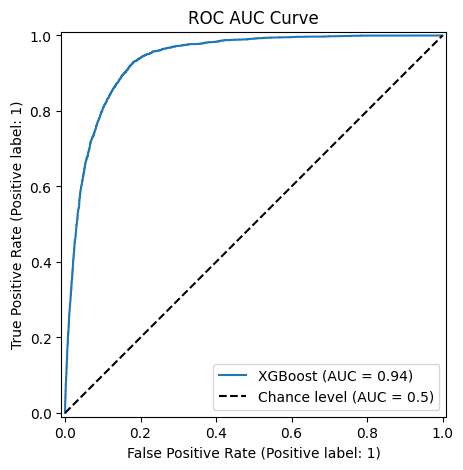

Finished Fold 2

========== FOLD 3 ==========
Fold 3 | AUC: 0.9360
F1: 0.7010 | Recall: 0.7345 | Precision: 0.6705


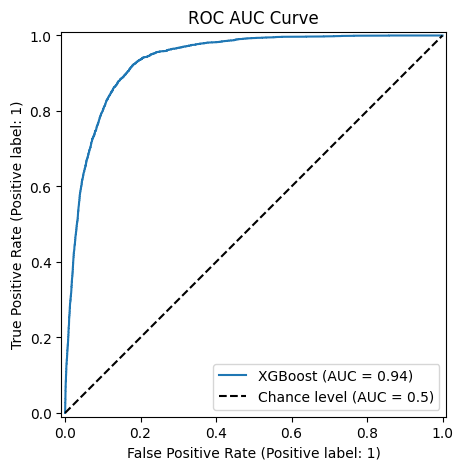

Finished Fold 3

========== FOLD 4 ==========
Fold 4 | AUC: 0.9340
F1: 0.6942 | Recall: 0.7409 | Precision: 0.6531


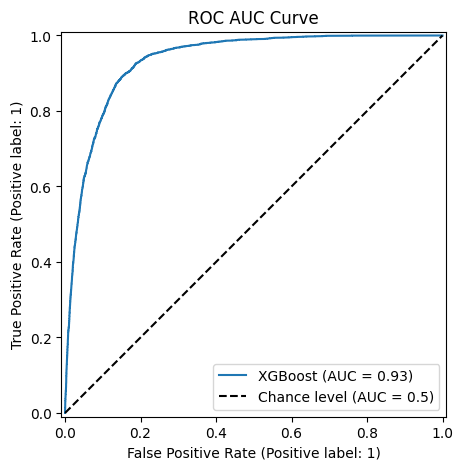

Finished Fold 4

========== FOLD 5 ==========
Fold 5 | AUC: 0.9397
F1: 0.7085 | Recall: 0.7489 | Precision: 0.6723


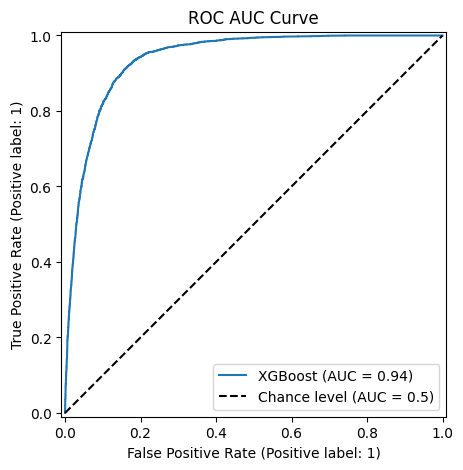

Finished Fold 5
Avg AUC: 0.9366
Avg F1: 0.7012
Avg Recall: 0.7416
Avg Precision: 0.6650
Std AUC: 0.001856941113581715


In [ ]:
xgbAucList = []
xgbF1List = []
xgbRecallList = []
xgbPrecisionList = []

print("==========XGBoost Cross Validation Training Loop==========")
for fold, (train_idx, val_idx) in enumerate(skf.split(subset_x, subset_y)):
    print(f"\n========== FOLD {fold + 1} ==========")
    
    # 1. Split data (using .iloc if X/y are pandas DataFrames)
    X_train, X_val = subset_x.iloc[train_idx], subset_x.iloc[val_idx]
    y_train, y_val = subset_y.iloc[train_idx], subset_y.iloc[val_idx]
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    # X_train_resampled, y_train_resampled = ada.fit_resample(X_train, y_train)

    model = XGBClassifier(
    n_estimators=100,      # number of boosting rounds (trees)
    max_depth=6,           # tree depth
    learning_rate=0.1,     # shrinkage per round
    subsample=0.8,         # row sampling per tree
    colsample_bytree=0.8,  # feature sampling per tree
    eval_metric='logloss'
)
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]
    
    auc = roc_auc_score(y_val, y_prob)
    f1 = f1_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)

    print(f"Fold {fold + 1} | AUC: {auc:.4f}")
    print(f"F1: {f1:.4f} | Recall: {recall:.4f} | Precision: {precision:.4f}")

    # ConfusionMatrixDisplay.from_predictions(y_val, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    RocCurveDisplay.from_estimator(model, X_val, y_val, ax=ax, name="XGBoost")
    ax.plot([0, 1], [0, 1], "k--", label="Chance level (AUC = 0.5)")
    ax.set_title("ROC AUC Curve")
    ax.legend(loc="lower right")
    plt.show()

    # explainer = shap.Explainer(model, X_train_resampled)
    # shap_values = explainer(X_val)

    # # 4. Plot the Beeswarm summary chart
    # shap.plots.beeswarm(shap_values)

    xgbAucList.append(auc)
    xgbF1List.append(f1)
    xgbRecallList.append(recall)
    xgbPrecisionList.append(precision)
              
    print(f"Finished Fold {fold + 1}")

print(f"Avg AUC: {(sum(xgbAucList) / n_splits):.4f}")
print(f"Avg F1: {(sum(xgbF1List) / n_splits):.4f}")
print(f"Avg Recall: {(sum(xgbRecallList) / n_splits):.4f}")
print(f"Avg Precision: {(sum(xgbPrecisionList) / n_splits):.4f}")
print(f"Std AUC: {np.std(xgbAucList)}")


### Without oversampling (10000 samples)
- Avg AUC: 0.7961
- Avg F1: 0.6768
- Avg Recall: 0.6476
- Avg Precision: 0.7091
- Std AUC: 0.011227993955145489

### With SMOTE 
- (50000 samples)
- Avg AUC: 0.9380
- Avg F1: 0.6928
- Avg Recall: 0.6803
- Avg Precision: 0.7061
- Std AUC: 0.0027307035663074416

- (100000 samples)
- Avg AUC: 0.9366
- Avg F1: 0.7012
- Avg Recall: 0.7416
- Avg Precision: 0.6650
- Std AUC: 0.001856941113581715

(200000 samples)
- Avg AUC: 0.9399
- Avg F1: 0.6997
- Avg Recall: 0.6903
- Avg Precision: 0.7095
- Std AUC: 0.0008880157870868589

(500000 samples)
- Avg AUC: 0.9402
- Avg F1: 0.6996
- Avg Recall: 0.6896
- Avg Precision: 0.7098
- Std AUC: 0.0008942851500033605

### With ADASYN 
- (50000 samples)
- Avg AUC: 0.9379
- Avg F1: 0.6930
- Avg Recall: 0.6819
- Avg Precision: 0.7048
- Std AUC: 0.0026846216264028214